# Option Pricing: Classical Methods and Risk Analytics

This notebook prices **European vanilla options** using three classical approaches and analyses their risk sensitivities:

| # | Method | Key idea |
|---|--------|----------|
| 1 | **Black-Scholes-Merton (BSM)** | Closed-form PDE solution under GBM |
| 2 | **Monte Carlo (MC)** | Risk-neutral expectation via simulation |
| 3 | **CRR Binomial Tree** | Discrete-time lattice, converges to BSM |

All models operate under the **risk-neutral measure** $\mathbb{Q}$, where the discounted stock price is a martingale and the option price equals the discounted expected payoff.

**Requirements:** Python 3.9+, `numpy`, `scipy`, `matplotlib` (all available via `pip install numpy scipy matplotlib`).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm, gaussian_kde
from scipy.optimize import brentq

np.random.seed(42)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.prop_cycle": plt.cycler(color=[
        "#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b"
    ]),
})

In [2]:
# ── Global Parameters ──────────────────────────────────────────────────────
# Calibrated to a typical large-cap equity option (e.g. S&P 500 constituent)
S0    = 100.0   # spot price (normalised)
K     = 100.0   # strike price  - ATM
r     = 0.05    # continuous risk-free rate  (≈ 5-yr US Treasury yield)
sigma = 0.20    # implied volatility  (20% ≈ long-run VIX average)
T     = 0.5     # time to maturity: 6 months

print(f"Spot S₀ = {S0:.0f}   Strike K = {K:.0f}   ATM option")
print(f"r = {r:.2%}   σ = {sigma:.2%}   T = {T:.1f} yr")

Spot S₀ = 100   Strike K = 100   ATM option
r = 5.00%   σ = 20.00%   T = 0.5 yr


---
## 1  Black-Scholes-Merton (BSM)

### Model

Under the **physical measure** the stock follows geometric Brownian motion (GBM):

$$dS_t = \mu\, S_t\, dt + \sigma\, S_t\, dW_t$$

By Girsanov's theorem, under the **risk-neutral measure** $\mathbb{Q}$ there exists a $\mathbb{Q}$-Brownian motion $\tilde{W}_t$ such that the drift becomes the risk-free rate:

$$dS_t = r\, S_t\, dt + \sigma\, S_t\, d\tilde{W}_t$$

Solving the Black-Scholes PDE (or equivalently computing the discounted $\mathbb{Q}$-expectation) yields the **closed-form prices**:

$$\boxed{C = S_0\,\Phi(d_1) - K e^{-r\tau}\,\Phi(d_2), \qquad P = K e^{-r\tau}\,\Phi(-d_2) - S_0\,\Phi(-d_1)}$$

where $\tau = T - t$ is time to expiry and

$$d_1 = \frac{\ln(S_0/K) + \bigl(r + \tfrac{1}{2}\sigma^2\bigr)\tau}{\sigma\sqrt{\tau}}, \qquad d_2 = d_1 - \sigma\sqrt{\tau}$$

**Put-call parity** is a model-free no-arbitrage identity:

$$C - P = S_0 - Ke^{-r\tau}$$

### Assumptions & Limitations

| Assumption | Real-world violation |
|---|---|
| Constant volatility $\sigma$ | Volatility smiles and term structure exist |
| Continuous trading, frictionless markets | Discrete rebalancing, transaction costs |
| Log-normal returns | Fat tails, jumps (Merton, Kou models) |
| No dividends | Extend with continuous yield $q$: replace $r \to r - q$ |

In [3]:
# ── BSM Helper Functions ────────────────────────────────────────────────────

def _d1d2(S, K, r, sigma, tau):
    '''Compute d1, d2. Handles array inputs.'''
    with np.errstate(divide="ignore", invalid="ignore"):
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    return d1, d1 - sigma * np.sqrt(tau)

def bs_call(S, K, r, sigma, tau):
    d1, d2 = _d1d2(S, K, r, sigma, tau)
    return S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)

def bs_put(S, K, r, sigma, tau):
    d1, d2 = _d1d2(S, K, r, sigma, tau)
    return K * np.exp(-r * tau) * norm.cdf(-d2) - S * norm.cdf(-d1)

# ── Greeks (call; Gamma & Vega are put/call symmetric) ──────────────────────

def bs_delta(S, K, r, sigma, tau, option="call"):
    d1, _ = _d1d2(S, K, r, sigma, tau)
    return norm.cdf(d1) if option == "call" else norm.cdf(d1) - 1

def bs_gamma(S, K, r, sigma, tau):
    d1, _ = _d1d2(S, K, r, sigma, tau)
    return norm.pdf(d1) / (S * sigma * np.sqrt(tau))

def bs_vega(S, K, r, sigma, tau):
    '''Vega in $ per 1% change in implied vol (market convention).'''
    d1, _ = _d1d2(S, K, r, sigma, tau)
    return S * norm.pdf(d1) * np.sqrt(tau) / 100

def bs_theta(S, K, r, sigma, tau, option="call"):
    '''Theta in $ per calendar day.'''
    d1, d2 = _d1d2(S, K, r, sigma, tau)
    decay = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(tau))
    if option == "call":
        return (decay - r * K * np.exp(-r * tau) * norm.cdf( d2)) / 365
    else:
        return (decay + r * K * np.exp(-r * tau) * norm.cdf(-d2)) / 365

def bs_rho(S, K, r, sigma, tau, option="call"):
    '''Rho in $ per 1% change in risk-free rate.'''
    _, d2 = _d1d2(S, K, r, sigma, tau)
    if option == "call":
        return  K * tau * np.exp(-r * tau) * norm.cdf( d2) / 100
    else:
        return -K * tau * np.exp(-r * tau) * norm.cdf(-d2) / 100

In [4]:
# ── Prices & Put-Call Parity Check ─────────────────────────────────────────
call_price = bs_call(S0, K, r, sigma, T)
put_price  = bs_put( S0, K, r, sigma, T)

parity_lhs = call_price - put_price
parity_rhs = S0 - K * np.exp(-r * T)

print(f"BSM Call price : {call_price:.4f}")
print(f"BSM Put  price : {put_price:.4f}")
print(f"Put-call parity  C − P = {parity_lhs:.6f}")
print(f"                 S − Ke⁻ʳᵀ = {parity_rhs:.6f}  ✓  (diff = {abs(parity_lhs-parity_rhs):.2e})")

BSM Call price : 6.8887
BSM Put  price : 4.4197
Put-call parity  C − P = 2.469009
                 S − Ke⁻ʳᵀ = 2.469009  ✓  (diff = 7.11e-15)


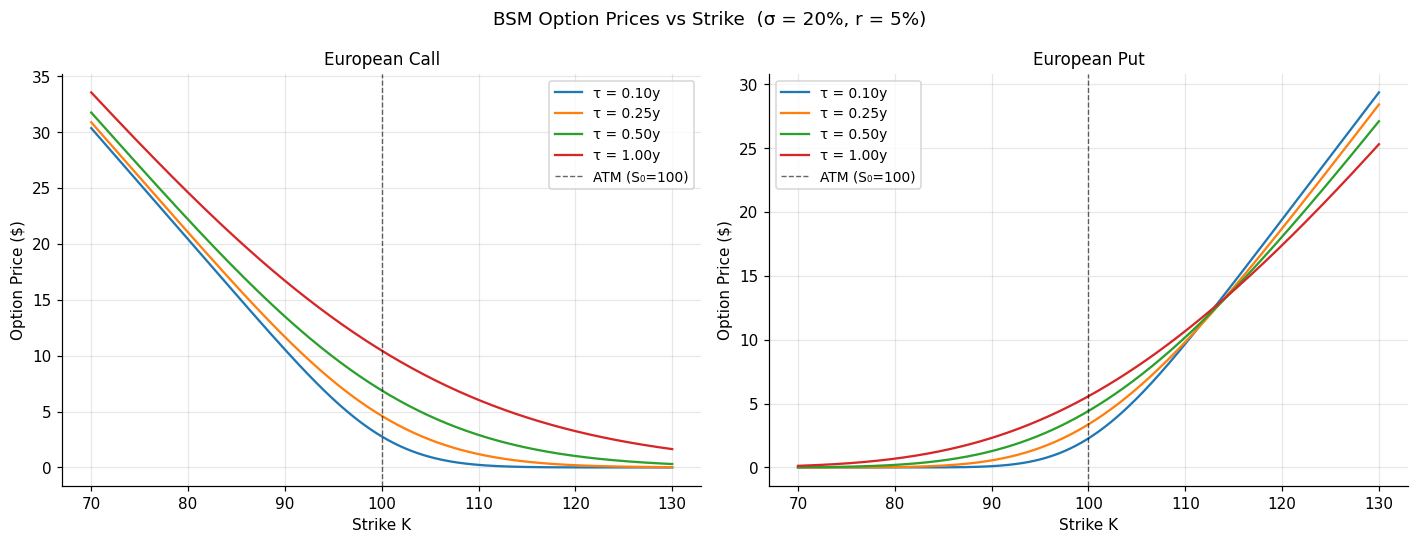

In [5]:
# ── BSM Price Curves: Call & Put vs Strike ──────────────────────────────────
strikes = np.linspace(70, 130, 300)
taus_plot = [0.1, 0.25, 0.5, 1.0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for tau in taus_plot:
    axes[0].plot(strikes, bs_call(S0, strikes, r, sigma, tau), label=f"τ = {tau:.2f}y")
    axes[1].plot(strikes, bs_put( S0, strikes, r, sigma, tau), label=f"τ = {tau:.2f}y")

for ax, title in zip(axes, ["European Call", "European Put"]):
    ax.axvline(S0, color="k", ls="--", lw=0.9, alpha=0.6, label="ATM (S₀=100)")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Strike K")
    ax.set_ylabel("Option Price ($)")
    ax.legend(fontsize=9)

fig.suptitle(f"BSM Option Prices vs Strike  (σ = {sigma:.0%}, r = {r:.0%})", fontsize=12)
plt.tight_layout()
plt.show()

---
## 2  Monte Carlo Simulation

### Risk-Neutral Exact Solution

By Itô's lemma, the exact solution to the risk-neutral GBM SDE is:

$$S_T = S_0 \exp\!\left[\left(r - \tfrac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}\,Z\right], \qquad Z \sim \mathcal{N}(0,1)$$

The option price is the discounted expected payoff:

$$C = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}\!\left[\max(S_T - K,\,0)\right] \;\approx\; e^{-rT}\frac{1}{N}\sum_{i=1}^{N}\max\!\left(S_T^{(i)} - K,\,0\right)$$

### Variance Reduction: Antithetic Variates

For each draw $Z^{(i)} \sim \mathcal{N}(0,1)$ we also evaluate the payoff at $-Z^{(i)}$.  Since the call payoff $\max(S_T(Z)-K,0)$ is monotone increasing in $Z$, the two realisations are **negatively correlated**, roughly halving the estimator variance at no extra cost:

$$\hat{C}_{\mathrm{AV}} = e^{-rT}\frac{1}{N}\sum_{i=1}^{N} \frac{h(Z^{(i)}) + h(-Z^{(i)})}{2}, \quad h(Z) \equiv \max(S_T(Z)-K,\,0)$$

### Limitations

- **Convergence rate** $O(N^{-1/2})$: halving the standard error costs $4\times$ as many paths.  
- Using the exact terminal formula above **eliminates discretisation error** (no Euler scheme needed for European options).  
- For path-dependent options (Asian, barrier) full path simulation with $N_{\text{steps}}$ increments per path is required.

In [6]:
# ── Monte Carlo with Antithetic Variates ────────────────────────────────────
N_MC = 100_000   # simulation paths

Z = np.random.standard_normal(N_MC)

def gbm_terminal(Z_):
    '''Terminal stock price under Q (exact, no discretisation error).'''
    return S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z_)

S_T_pos = gbm_terminal( Z)
S_T_neg = gbm_terminal(-Z)   # antithetic pair

# Averaged payoff per pair
payoffs_av = 0.5 * (np.maximum(S_T_pos - K, 0) + np.maximum(S_T_neg - K, 0))

mc_price = np.exp(-r * T) * payoffs_av.mean()
mc_se    = np.exp(-r * T) * payoffs_av.std() / np.sqrt(N_MC)

print(f"MC (antithetic, N = {N_MC:,})  call: {mc_price:.4f}  ±  {1.96*mc_se:.4f}  (95% CI)")
print(f"BSM exact                      call: {call_price:.4f}")
print(f"Difference: {abs(mc_price - call_price):.4f}")

MC (antithetic, N = 100,000)  call: 6.8958  ±  0.0305  (95% CI)
BSM exact                      call: 6.8887
Difference: 0.0071


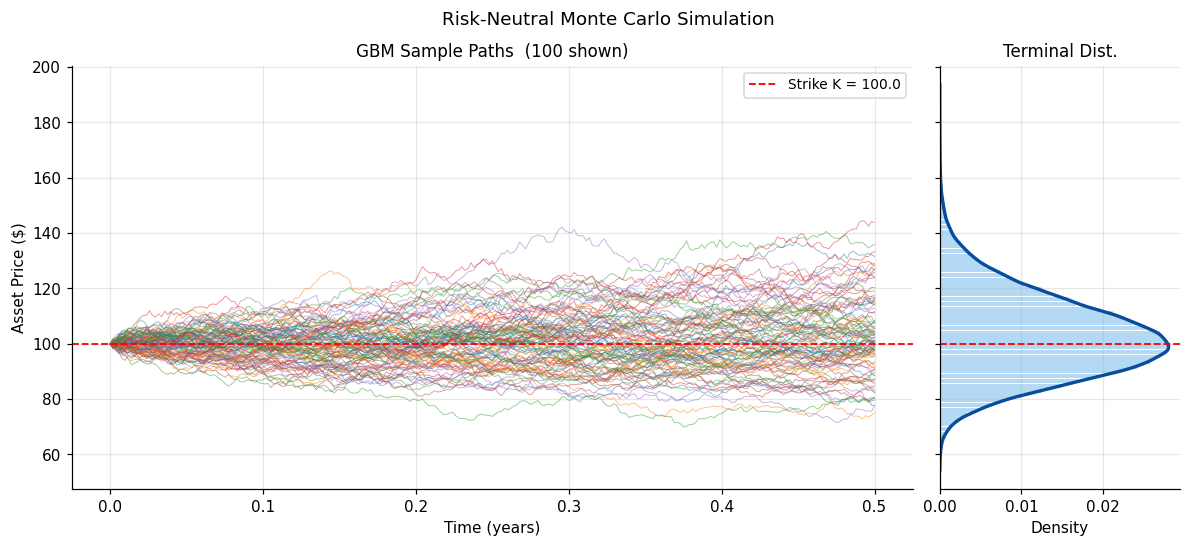

In [7]:
# ── MC Path Visualisation & Terminal Distribution ───────────────────────────
N_PLOT  = 100    # paths to display
N_STEPS = 252    # daily grid for path illustration

dt_vis  = T / N_STEPS
Z_paths = np.random.standard_normal((N_PLOT, N_STEPS))
log_inc = (r - 0.5 * sigma**2) * dt_vis + sigma * np.sqrt(dt_vis) * Z_paths
S_paths = np.hstack([np.full((N_PLOT, 1), S0),
                     np.exp(np.log(S0) + np.cumsum(log_inc, axis=1))])
t_grid  = np.linspace(0, T, N_STEPS + 1)

# Large sample for the terminal distribution histogram
S_T_all = gbm_terminal(np.random.standard_normal(200_000))

fig = plt.figure(figsize=(13, 5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[3.5, 1], wspace=0.05)

ax_l = fig.add_subplot(gs[0])
for path in S_paths:
    ax_l.plot(t_grid, path, lw=0.6, alpha=0.50)
ax_l.axhline(K, color="red", ls="--", lw=1.2, label=f"Strike K = {K}")
ax_l.set_title(f"GBM Sample Paths  ({N_PLOT} shown)", fontsize=11)
ax_l.set_xlabel("Time (years)")
ax_l.set_ylabel("Asset Price ($)")
ax_l.legend(fontsize=9)

ax_r = fig.add_subplot(gs[1], sharey=ax_l)
counts, edges = np.histogram(S_T_all, bins=80, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])
ax_r.barh(centers, counts, height=(edges[1] - edges[0]) * 0.9,
          color="#A7D3F3", alpha=0.85, edgecolor="none")
y_k = np.linspace(S_T_all.min(), S_T_all.max(), 400)
ax_r.plot(gaussian_kde(S_T_all)(y_k), y_k, color="#084C9E", lw=2.2)
ax_r.axhline(K, color="red", ls="--", lw=1.2)
ax_r.set_title("Terminal Dist.", fontsize=11)
ax_r.set_xlabel("Density")
ax_r.tick_params(axis="y", labelleft=False)
ax_r.set_ylim(ax_l.get_ylim())

fig.suptitle("Risk-Neutral Monte Carlo Simulation", fontsize=12)
plt.show()

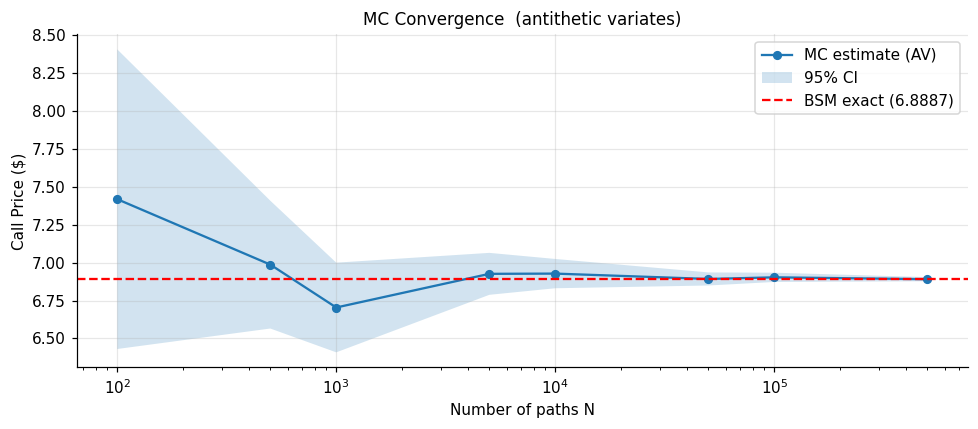

In [8]:
# ── MC Convergence with Antithetic Variates ─────────────────────────────────
ns = [100, 500, 1_000, 5_000, 10_000, 50_000, 100_000, 500_000]
mc_means, mc_cis = [], []

for n in ns:
    Z_ = np.random.standard_normal(n)
    pay = 0.5 * (np.maximum(gbm_terminal( Z_) - K, 0) +
                 np.maximum(gbm_terminal(-Z_) - K, 0))
    disc = np.exp(-r * T)
    mc_means.append(disc * pay.mean())
    mc_cis.append(1.96 * disc * pay.std() / np.sqrt(n))

mc_means = np.array(mc_means)
mc_cis   = np.array(mc_cis)

plt.figure(figsize=(9, 4))
plt.semilogx(ns, mc_means, "o-", ms=5, label="MC estimate (AV)")
plt.fill_between(ns, mc_means - mc_cis, mc_means + mc_cis, alpha=0.2, label="95% CI")
plt.axhline(call_price, color="red", ls="--", lw=1.5, label=f"BSM exact ({call_price:.4f})")
plt.title("MC Convergence  (antithetic variates)", fontsize=11)
plt.xlabel("Number of paths N")
plt.ylabel("Call Price ($)")
plt.legend()
plt.tight_layout()
plt.show()

---
## 3  Cox-Ross-Rubinstein (CRR) Binomial Tree

### Model

The continuous-time GBM is approximated by a **recombining binomial lattice** with step size $\Delta t = T/N$.  At each node the stock moves by:

| Move | Factor | Risk-neutral probability |
|------|--------|--------------------------|
| Up   | $u = e^{\,\sigma\sqrt{\Delta t}}$ | $p = \dfrac{e^{r\Delta t} - d}{u - d}$ |
| Down | $d = 1/u = e^{-\sigma\sqrt{\Delta t}}$ | $1 - p$ |

The price at node $(i,j)$ - step $i$, with $j$ up-moves - is $S_{i,j} = S_0\,u^j\,d^{i-j}$.  The tree recombines because $ud = 1$, giving $N+1$ distinct terminal nodes.

**Backward induction** propagates values from expiry to time 0:

$$V_{i,j} = e^{-r\Delta t}\!\left[p\,V_{i+1,\,j+1} + (1-p)\,V_{i+1,\,j}\right]$$

with terminal condition $V_{N,j} = \max(S_{N,j} - K,\,0)$.  The price is $V_{0,0}$.

> **Convergence:** CRR $\to$ BSM at rate $O(1/N)$ with an oscillatory bias depending on whether the strike falls on a node.  Odd $N$ typically gives smoother convergence ATM.

### Limitations

- American options: add early-exercise check $V_{i,j} \leftarrow \max(V_{i,j},\,S_{i,j}-K)$ at each node.  
- Stochastic volatility requires a 2D lattice or PDE/MC methods.  
- Slow convergence for short maturities; Leisen-Reimer tree or Richardson extrapolation can help.

In [9]:
# ── CRR Binomial Tree (vectorised) ──────────────────────────────────────────

def crr_price(S, K, r, sigma, T, N, option="call"):
    '''Fully vectorised CRR for European options - no inner loop.'''
    dt  = T / N
    u   = np.exp(sigma * np.sqrt(dt))
    d   = 1.0 / u
    p   = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)

    # Terminal stock prices at all N+1 nodes
    j = np.arange(N + 1, dtype=float)
    S_T = S * (u ** j) * (d ** (N - j))

    # Terminal payoff
    C = np.maximum(S_T - K, 0.0) if option == "call" else np.maximum(K - S_T, 0.0)

    # Backward induction - vectorised slice update
    for _ in range(N):
        C = disc * (p * C[1:] + (1.0 - p) * C[:-1])

    return float(C[0])

N_CRR   = 500
crr_call = crr_price(S0, K, r, sigma, T, N_CRR, option="call")
crr_put  = crr_price(S0, K, r, sigma, T, N_CRR, option="put")

print(f"CRR (N = {N_CRR})  call: {crr_call:.4f}   put: {crr_put:.4f}")
print(f"BSM            call: {call_price:.4f}   put: {put_price:.4f}")
print(f"CRR call error: {abs(crr_call - call_price)*100:.4f}¢")

CRR (N = 500)  call: 6.8859   put: 4.4169
BSM            call: 6.8887   put: 4.4197
CRR call error: 0.2825¢


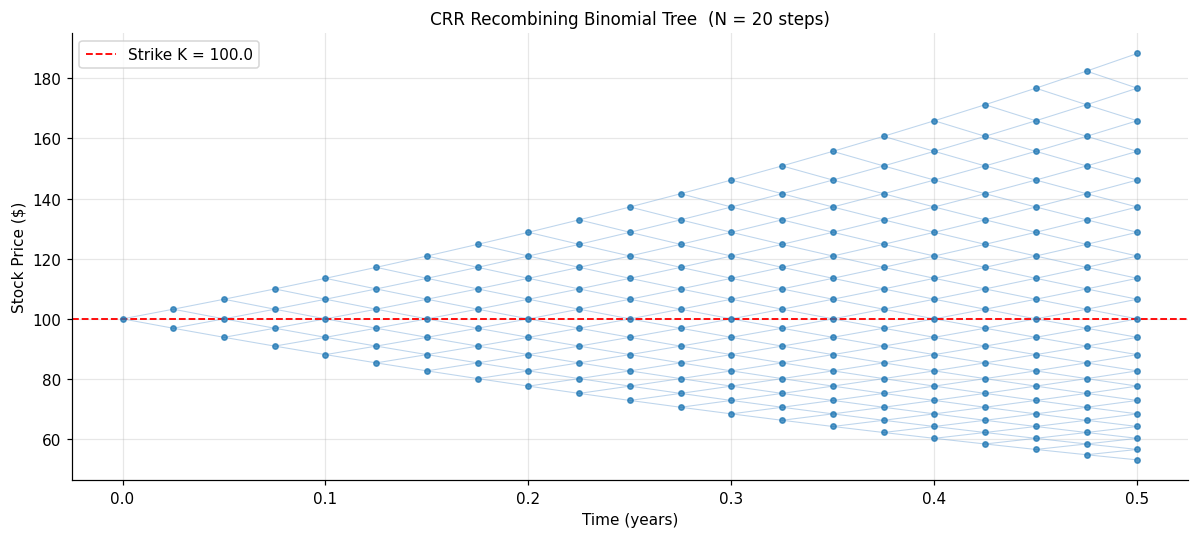

In [10]:
# ── CRR Tree Visualisation (small N for clarity) ────────────────────────────
N_vis  = 20
dt_vis = T / N_vis
u_vis  = np.exp(sigma * np.sqrt(dt_vis))
d_vis  = 1.0 / u_vis

S_tree = np.zeros((N_vis + 1, N_vis + 1))
for i in range(N_vis + 1):
    for j in range(i + 1):
        S_tree[i, j] = S0 * (u_vis ** j) * (d_vis ** (i - j))

fig, ax = plt.subplots(figsize=(11, 5))

for i in range(N_vis + 1):
    t_vals = np.full(i + 1, i * dt_vis)
    ax.plot(t_vals, S_tree[i, :i + 1], "o", ms=3.5, color="#1f77b4", alpha=0.75, zorder=3)

    if i < N_vis:
        for j in range(i + 1):
            ax.plot([i*dt_vis, (i+1)*dt_vis], [S_tree[i,j], S_tree[i+1,j+1]],
                    lw=0.7, color="#93BAE0", alpha=0.6, zorder=2)   # up branch
            ax.plot([i*dt_vis, (i+1)*dt_vis], [S_tree[i,j], S_tree[i+1,j  ]],
                    lw=0.7, color="#93BAE0", alpha=0.6, zorder=2)   # down branch

ax.axhline(K, color="red", ls="--", lw=1.2, label=f"Strike K = {K}")
ax.set_title(f"CRR Recombining Binomial Tree  (N = {N_vis} steps)", fontsize=11)
ax.set_xlabel("Time (years)")
ax.set_ylabel("Stock Price ($)")
ax.legend()
plt.tight_layout()
plt.show()

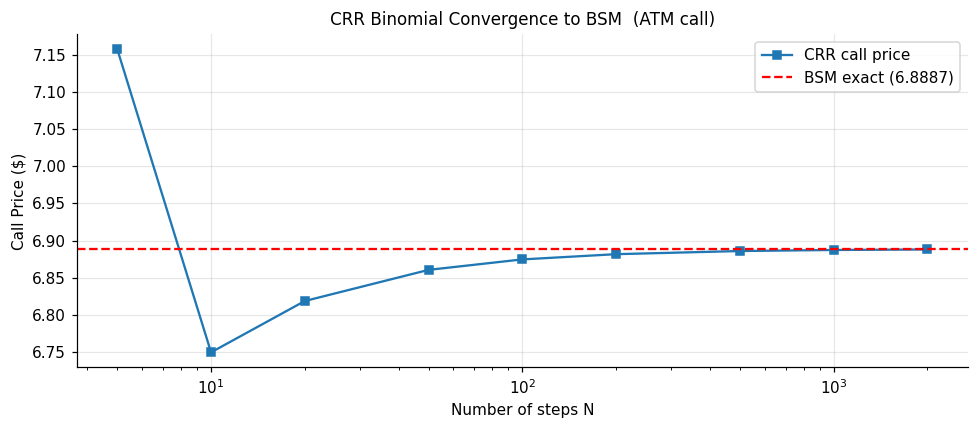

In [11]:
# ── CRR Convergence to BSM ───────────────────────────────────────────────────
Ns_crr = [5, 10, 20, 50, 100, 200, 500, 1000, 2000]
crr_prices_n = [crr_price(S0, K, r, sigma, T, N) for N in Ns_crr]

plt.figure(figsize=(9, 4))
plt.semilogx(Ns_crr, crr_prices_n, "s-", ms=5, label="CRR call price")
plt.axhline(call_price, color="red", ls="--", lw=1.5, label=f"BSM exact ({call_price:.4f})")
plt.title("CRR Binomial Convergence to BSM  (ATM call)", fontsize=11)
plt.xlabel("Number of steps N")
plt.ylabel("Call Price ($)")
plt.legend()
plt.tight_layout()
plt.show()

---
## 4  Model Comparison

All three methods price the same ATM European call under identical parameters.  BSM is the reference.

In [12]:
print(f"{'Method':<32} {'Call':>10}  {'Note'}")
print("─" * 62)
print(f"{'Black-Scholes-Merton':<32} {call_price:>10.4f}  closed form")
print(f"{'Monte Carlo (AV, N=100k)':<32} {mc_price:>10.4f}  ±{1.96*mc_se:.4f}  95% CI")
print(f"{'CRR Binomial (N=500)':<32} {crr_call:>10.4f}  error {abs(crr_call-call_price)*100:.3f}¢")

Method                                 Call  Note
──────────────────────────────────────────────────────────────
Black-Scholes-Merton                 6.8887  closed form
Monte Carlo (AV, N=100k)             6.8958  ±0.0305  95% CI
CRR Binomial (N=500)                 6.8859  error 0.283¢


---
## 5  Option Greeks

Greeks measure the sensitivity of the option price $V$ to changes in market parameters.

| Greek | Symbol | Definition | BSM (call) |
|-------|--------|-----------|------------|
| Delta  | $\Delta$ | $\partial V / \partial S$               | $\Phi(d_1)$ |
| Gamma  | $\Gamma$ | $\partial^2 V / \partial S^2$           | $\phi(d_1)\,/\,(S\sigma\sqrt{\tau})$ |
| Vega   | $\mathcal{V}$ | $\partial V / \partial\sigma \cdot 0.01$   | $S\phi(d_1)\sqrt{\tau}\,/\,100$ |
| Theta  | $\Theta$ | $\partial V / \partial t$ per day      | $\left[-\frac{S\phi(d_1)\sigma}{2\sqrt{\tau}} - rKe^{-r\tau}\Phi(d_2)\right]/365$ &nbsp;*(negative for long options)*|
| Rho    | $\rho$   | $\partial V / \partial r$ per 1%       | $K\tau e^{-r\tau}\Phi(d_2)\,/\,100$ |

$\phi(\cdot)$ denotes the standard normal PDF; $\Phi(\cdot)$ the CDF.

**Key intuitions:**  
- $\Delta \in (0,1)$ for calls; approaches 0.5 ATM as $\tau \to 0$ (for $r,\sigma > 0$, ATM delta is always slightly above 0.5 for finite $\tau$).  
- $\Gamma$ peaks ATM and spikes near expiry - gamma-hedging is expensive when $\tau$ is small.  
- $\Theta < 0$ for long calls: holding an option costs time value daily.  Some practitioners quote theta as a positive number representing time decay earned by a short position — the sign convention here follows the standard long-option perspective ($\partial V / \partial t$).  
- $\mathcal{V} > 0$ for both calls and puts - any option benefits from higher uncertainty.

In [13]:
# Sanity check at current parameters
print("── ATM Greeks (Call, S=K=100, σ=20%, T=0.5y, r=5%) ──")
print(f"  Delta:  {bs_delta(S0, K, r, sigma, T):.4f}   [0=OTM … 1=deep ITM]")
print(f"  Gamma:  {bs_gamma(S0, K, r, sigma, T):.4f}   [Δ change per $1 move in S]")
print(f"  Vega:   {bs_vega(S0, K, r, sigma, T):.4f}   [$ per 1% σ move]")
print(f"  Theta:  {bs_theta(S0, K, r, sigma, T):.4f}   [$ per calendar day]")
print(f"  Rho:    {bs_rho(S0, K, r, sigma, T):.4f}   [$ per 1% rate move]")

── ATM Greeks (Call, S=K=100, σ=20%, T=0.5y, r=5%) ──
  Delta:  0.5977   [0=OTM … 1=deep ITM]
  Gamma:  0.0274   [Δ change per $1 move in S]
  Vega:   0.2736   [$ per 1% σ move]
  Theta:  -0.0222   [$ per calendar day]
  Rho:    0.2644   [$ per 1% rate move]


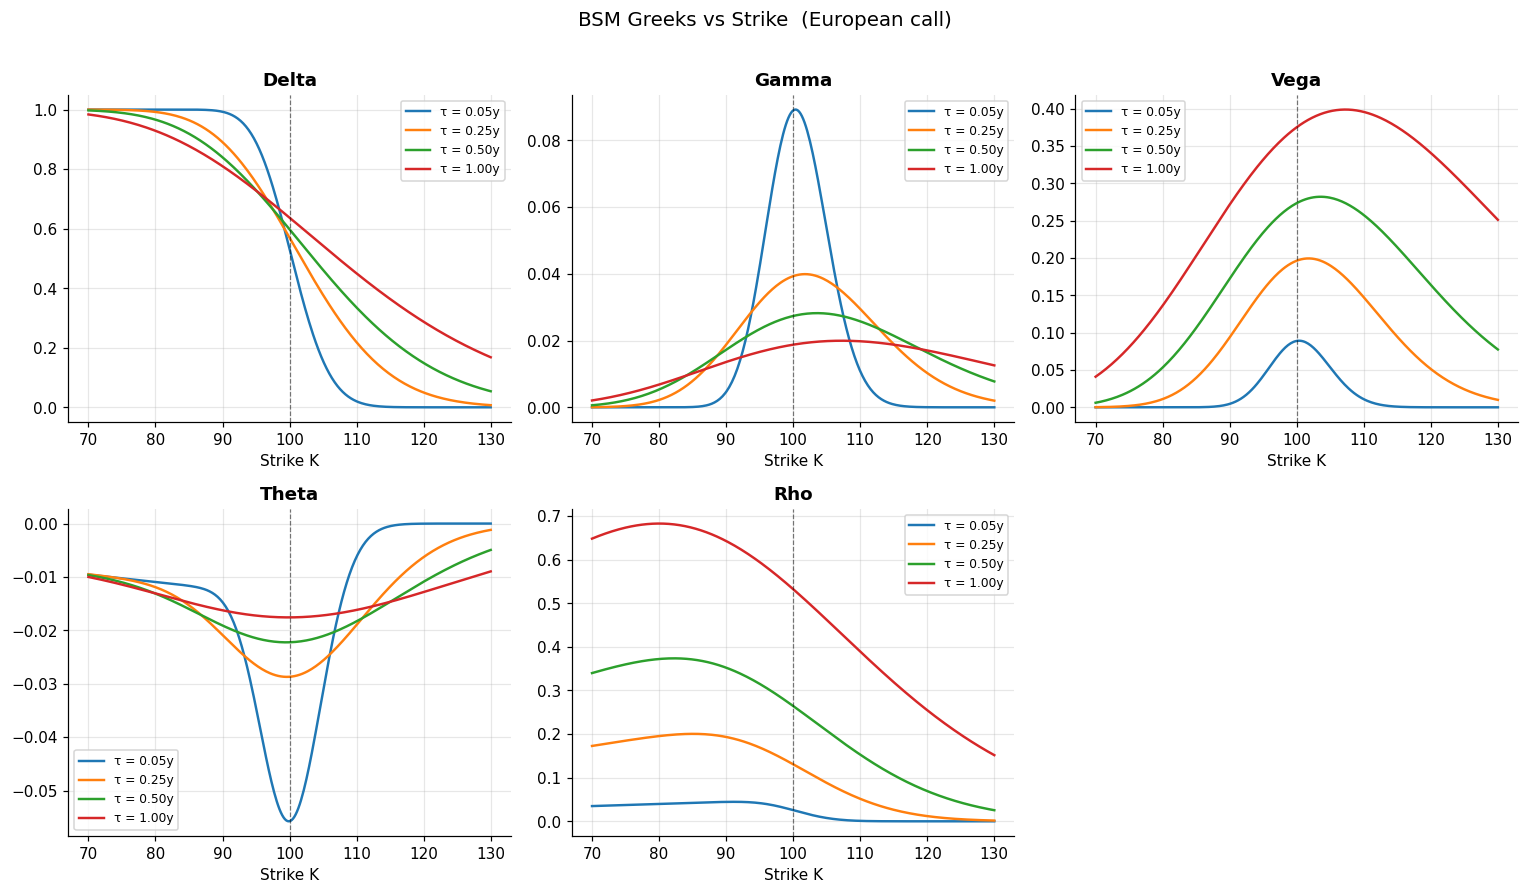

In [14]:
# ── All 5 Greeks vs Strike, Multiple Maturities ─────────────────────────────
strikes_g  = np.linspace(70, 130, 300)
taus_greek = [0.05, 0.25, 0.5, 1.0]   # include near-expiry to show gamma spike

greek_specs = [
    ("Delta",  lambda K_, tau: bs_delta(S0, K_, r, sigma, tau)),
    ("Gamma",  lambda K_, tau: bs_gamma(S0, K_, r, sigma, tau)),
    ("Vega",   lambda K_, tau: bs_vega( S0, K_, r, sigma, tau)),
    ("Theta",  lambda K_, tau: bs_theta(S0, K_, r, sigma, tau)),
    ("Rho",    lambda K_, tau: bs_rho(  S0, K_, r, sigma, tau)),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, (name, fn) in zip(axes, greek_specs):
    for tau in taus_greek:
        vals = np.vectorize(fn)(strikes_g, tau)
        ax.plot(strikes_g, vals, lw=1.6, label=f"τ = {tau:.2f}y")
    ax.axvline(S0, color="k", ls="--", lw=0.8, alpha=0.5)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Strike K")
    ax.legend(fontsize=8)

axes[-1].set_visible(False)   # hide unused 6th panel

fig.suptitle("BSM Greeks vs Strike  (European call)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

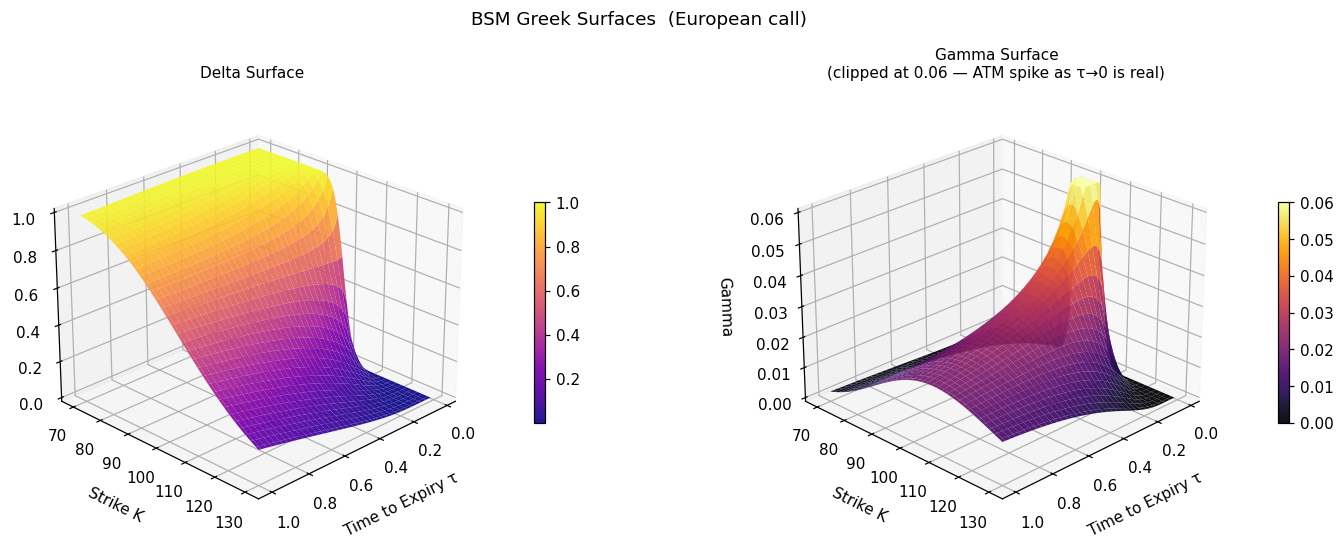

In [15]:
# ── 3D Surfaces: Delta and Gamma ─────────────────────────────────────────
K_g   = np.linspace(70, 130, 70)
tau_g = np.linspace(0.02, 1.0, 70)
TT, KK = np.meshgrid(tau_g, K_g)   # τ on X-axis, K on Y-axis (standard convention)

fig, axes3d = plt.subplots(1, 2, figsize=(14, 5), subplot_kw={"projection": "3d"})

configs = [
    ("Delta", lambda K_, T_: bs_delta(S0, K_, r, sigma, T_), "plasma",  None),
    ("Gamma", lambda K_, T_: bs_gamma(S0, K_, r, sigma, T_), "inferno", 0.06),
]

for ax, (name, fn, cmap, zlim) in zip(axes3d, configs):
    ZZ = np.vectorize(fn)(KK, TT)
    if zlim is not None:
        ZZ_plot = np.clip(ZZ, 0, zlim)   # clip for visibility; spike noted in title
    else:
        ZZ_plot = ZZ

    surf = ax.plot_surface(TT, KK, ZZ_plot, cmap=cmap, alpha=0.93,
                           linewidth=0, antialiased=True)
    cbar = fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.08)
    cbar.set_label(name, fontsize=9)

    title = f"{name} Surface"
    if zlim is not None:
        title += f"\n(clipped at {zlim} — ATM spike as \u03c4\u21920 is real)"
    ax.set_title(title, pad=10, fontsize=10)
    ax.set_xlabel("Time to Expiry \u03c4", labelpad=8)   # τ on X
    ax.set_ylabel("Strike K",              labelpad=8)   # K on Y
    ax.set_zlabel("",                    labelpad=8)
    ax.view_init(elev=25, azim=45)

fig.suptitle("BSM Greek Surfaces  (European call)", fontsize=12)
plt.tight_layout()
plt.show()


---
## 6  Implied Volatility

BSM can be **inverted** to recover the volatility $\hat{\sigma}$ that makes the model price match an observed market price $C^{\text{mkt}}$:

$$C^{\text{BSM}}(S, K, r, \hat{\sigma}, \tau) = C^{\text{mkt}} \quad\Longrightarrow\quad \hat{\sigma} = \text{IV}(K, \tau)$$

There is no closed form for $\hat{\sigma}$; we use **Brent's method** — a bracketed, super-linearly convergent root-finding algorithm.

### The Volatility Smile and Surface

If BSM were the true data-generating process, implied vol would be **flat** across all strikes and maturities.  In equity markets it is not — and the full structure has two dimensions:

- **Skew** $\partial\,\text{IV}/\partial K < 0$: OTM puts trade at elevated IV relative to ATM, reflecting demand for downside crash protection and empirically negative return skewness.
- **Term structure** $\partial\,\text{IV}/\partial\tau$: short-dated IV is elevated and volatile; long-dated IV reverts toward a long-run level.  The skew itself steepens at short maturities, roughly as $1/\sqrt{\tau}$ (consistent with SABR-type models).

The **vol surface** $\hat{\sigma}(K, \tau)$ encodes all of this simultaneously and is the central object used by vol desks to mark books and hedge vega risk.


> **No-arbitrage constraints:** A valid volatility surface must satisfy butterfly-spread non-negativity ($\partial^2 C / \partial K^2 \geq 0$, equivalent to positive risk-neutral density) and calendar-spread monotonicity (total variance $\hat{\sigma}^2(K,\tau)\cdot\tau$ non-decreasing in $\tau$).  The synthetic surface below is illustrative and is **not** checked against these conditions; a production surface calibration would enforce them explicitly (e.g. via SVI with Roger-Lee moment constraints).

> The surface below is **synthetic**, built from a parametric model (negative log-moneyness skew + curvature + mild term structure).  Real surfaces are calibrated daily to live option chains.

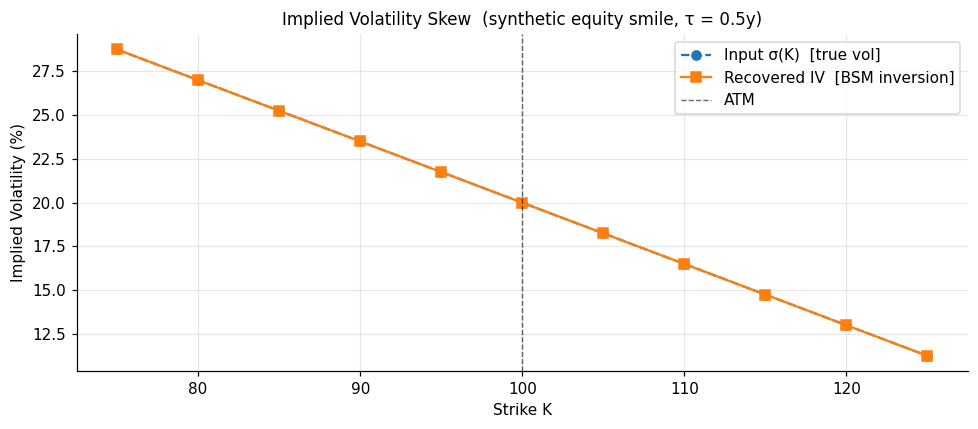

  Strike    True σ    IV rec    Error (μvol)
─────────────────────────────────────────────
      75    28.75%    28.75%           0.0
      80    27.00%    27.00%           0.0
      85    25.25%    25.25%           0.0
      90    23.50%    23.50%           0.0
      95    21.75%    21.75%           0.0
     100    20.00%    20.00%           0.0
     105    18.25%    18.25%           0.0
     110    16.50%    16.50%           0.0
     115    14.75%    14.75%           0.0
     120    13.00%    13.00%           0.0
     125    11.25%    11.25%           0.0


In [16]:
# ── Implied Volatility: Solver + Synthetic 2D Smile ────────────────────────

def implied_vol(mkt_price, S, K, r, tau, lo=1e-6, hi=10.0):
    '''Brent's method to invert BSM call price.  Returns nan if no bracket.'''
    f = lambda sig: bs_call(S, K, r, sig, tau) - mkt_price
    try:
        return brentq(f, lo, hi, xtol=1e-10, maxiter=500)
    except ValueError:
        return np.nan

# Synthetic equity skew anchored at global sigma (ATM = 20%):
#   σ(K) = sigma − 0.0035 × (K − S0)
#   → 28.75% at K=75 (deep OTM put),  11.25% at K=125 (OTM call)
K_smile   = np.array([75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125], dtype=float)
true_vols = sigma - 0.0035 * (K_smile - S0)
tau_smile = 0.5

mkt_prices = np.array([bs_call(S0, k, r, v, tau_smile)
                        for k, v in zip(K_smile, true_vols)])

iv_rec = np.array([implied_vol(p, S0, k, r, tau_smile)
                   for p, k in zip(mkt_prices, K_smile)])

plt.figure(figsize=(9, 4))
plt.plot(K_smile, true_vols * 100, "o--", lw=1.5, label="Input σ(K)  [true vol]")
plt.plot(K_smile, iv_rec   * 100, "s-",  lw=1.5, ms=7, label="Recovered IV  [BSM inversion]")
plt.axvline(S0, color="k", ls="--", lw=0.9, alpha=0.6, label="ATM")
plt.title("Implied Volatility Skew  (synthetic equity smile, τ = 0.5y)", fontsize=11)
plt.xlabel("Strike K")
plt.ylabel("Implied Volatility (%)")
plt.legend()
plt.tight_layout()
plt.show()

# Note: the round-trip error below is zero by construction — we invert the
# same BSM model that generated the prices, so recovery is exact up to the
# Brent solver tolerance (1e-10).  This validates the solver, not the vol model.
print(f"{'Strike':>8}  {'True σ':>8}  {'IV rec':>8}  {'Error (μvol)':>14}")
print("─" * 45)
for k, tv, iv in zip(K_smile, true_vols, iv_rec):
    print(f"{k:>8.0f}  {tv*100:>7.2f}%  {iv*100:>7.2f}%  {abs(tv-iv)*1e6:>12.1f}")

### Parameterisation Note

The 2D smile above uses **absolute strike distance** $K - S_0$ as the moneyness measure, which is common for quick illustration but is not scale-invariant.  The 3D surface below uses **log-moneyness** $m = \log(K/S_0)$, which is the standard choice in quantitative finance (SABR, SVI, and most calibration frameworks use $m$ or $\log(K/F)$).

As a result the two sections represent **two different synthetic constructions** evaluated at the same parameter set — they are not the same model sliced at $\tau = 0.5$.  In a production implementation you would pick one convention and apply it consistently across all visualisations.  The industry standard is **log-moneyness relative to the forward** $m = \log(K/F)$ where $F = S_0 e^{r\tau}$ is the at-the-money forward price; this choice is used in SABR, SVI, and most vol-surface calibration frameworks because it is scale-invariant and automatically adjusts for the cost of carry.

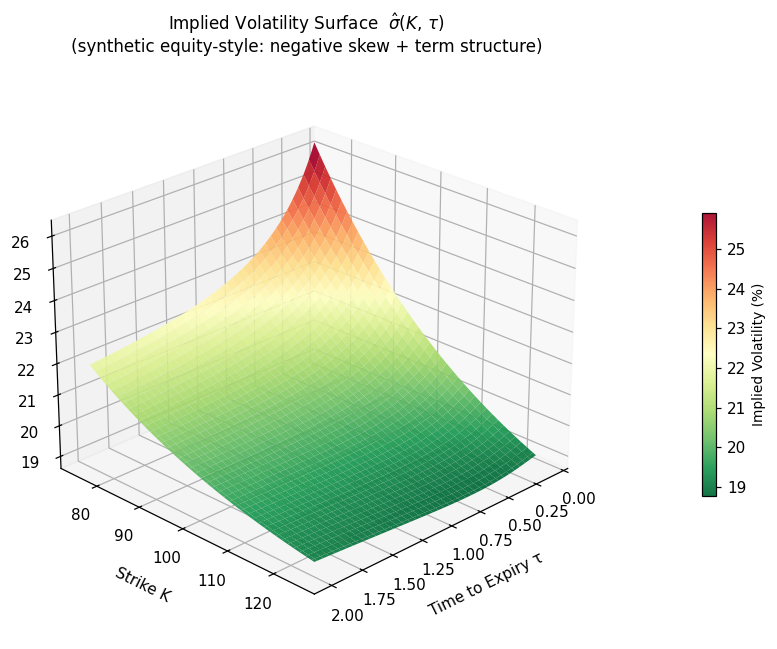

ATM IV at T=0.5y:  20.45%  (global sigma = 20.00%, spread = +0.45 vol pts from term structure)
K=80  IV at T=0.5y: 22.90%
K=120 IV at T=0.5y: 19.03%


In [17]:
# ── 3D Implied Volatility Surface ────────────────────────────────────────────

def parametric_iv(K, tau):
    m         = np.log(K / S0)
    sigma_atm = sigma + 0.02 * np.exp(-3 * tau)           # mild ATM term structure
    skew      = -0.08 / np.sqrt(tau + 0.25)               # negative equity skew (smooth)
    curv      = 0.05  + 0.08 * np.exp(-2 * tau)           # smile curvature
    return sigma_atm + skew * m + curv * m**2

K_surf   = np.linspace(75, 125, 80)
tau_surf = np.linspace(0.10, 2.0, 80)
TT, KK   = np.meshgrid(tau_surf, K_surf)   # τ on X-axis, K on Y-axis
IV_surf  = parametric_iv(KK, TT)

fig = plt.figure(figsize=(13, 6))
ax  = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(TT, KK, IV_surf * 100,
                       cmap="jet", alpha=0.92, linewidth=0, antialiased=True)

cbar = fig.colorbar(surf, ax=ax, shrink=0.50, pad=0.08)
cbar.set_label("Implied Volatility (%)", fontsize=9)

ax.set_title("Implied Volatility Surface  $\\hat{\\sigma}(K,\\,\\tau)$\n"
             "(synthetic equity-style: negative skew + term structure)", fontsize=11, pad=12)
ax.set_xlabel("Time to Expiry \u03c4", labelpad=8)
ax.set_ylabel("Strike K",              labelpad=8)
ax.set_zlabel("IV (%)",               labelpad=8)
ax.view_init(elev=25, azim=45)

plt.tight_layout()
plt.show()

iv_atm = parametric_iv(S0, T)
print(f"ATM IV at T={T}y:  {iv_atm:.2%}  (global sigma = {sigma:.2%}, "
      f"spread = {(iv_atm - sigma)*100:+.2f} vol pts from term structure)")
print(f"K=80  IV at T={T}y: {parametric_iv(80,  T):.2%}")
print(f"K=120 IV at T={T}y: {parametric_iv(120, T):.2%}")
